In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# set the themes
sns.set_theme(style="whitegrid")
%matplotlib inline

## Environment Setup

This section imports the necessary Python libraries and configures visualization settings:

- **pandas**: Core library for data manipulation, providing DataFrame structures and merging capabilities
- **matplotlib.pyplot**: Base plotting library for creating visualizations
- **seaborn**: Advanced statistical visualization library built on matplotlib
- **numpy**: Numerical computing library for efficient array operations and vectorized calculations

The Seaborn theme is set to `"whitegrid"` for clean, professional-looking plots. The `%matplotlib inline` magic command ensures plots render directly within the notebook.

# Carbon Emissions and Economic Analysis: Data Processing Pipeline

## Overview

This notebook establishes the data preprocessing pipeline for analyzing the relationship between carbon dioxide emissions and economic development. By integrating historical CO2 emissions data with GDP statistics, we create a comprehensive dataset for exploring carbon-economic dynamics across countries and time periods.

## Data Sources

1. **CO2 Emissions Data**: Our World in Data - Comprehensive emissions dataset (1750-2024)
2. **GDP Data**: World Bank World Development Indicators - Economic output in current USD (1960-2024)

## Processing Workflow

The notebook executes the following operations:
1. Import and clean CO2 emissions data (post-1900)
2. Load and transform GDP data from wide to long format
3. Merge datasets on country-year identifiers
4. Calculate per-capita metrics for comparative analysis
5. Validate data quality and coverage

## Requirements

- `pandas`: Data manipulation and analysis
- `matplotlib`: Visualization library
- `seaborn`: Statistical data visualization
- `numpy`: Numerical computing for vectorized operations

## Data Import and Preprocessing: CO2 Emissions Dataset

### Objective
Load and clean the CO2 emissions dataset, focusing on the 20th and 21st centuries to align with GDP data availability and ensure analytical relevance.

### Data Source
The dataset originates from Our World in Data, containing comprehensive historical CO2 emissions data with 79 columns spanning 1750-2024.

### Processing Steps

1. **Data Loading**: Import the complete CO2 emissions dataset from CSV format

2. **Column Selection**: Reduce the dataset to five core variables:
   - `country`: Country name for identification
   - `year`: Temporal dimension for time-series analysis
   - `iso_code`: ISO 3166-1 alpha-3 country code for standardized merging
   - `population`: Population count for per-capita calculations
   - `co2`: Total CO2 emissions in million tonnes

3. **Entity Filtering**: Remove non-country aggregates to maintain data integrity:
   - Continental aggregates (e.g., "Africa", "Europe")
   - Regional groupings (e.g., "OECD", "EU-27")
   - Income classifications (e.g., "High income")
   
   These aggregates lack ISO country codes and are identified by null or empty `iso_code` values.

4. **Temporal Filtering**: Restrict data to post-1900 observations (`year > 1900`)
   - Aligns with the modern industrial era
   - Reduces data volume while retaining relevant historical context
   - Improves overlap with GDP data (available from 1960)

### Output
A streamlined dataset with 27,032 country-year observations spanning 1901-2024, ready for economic integration.

In [2]:
df = pd.read_csv('data/co2_data.csv')

# choose what columns to keep (can be changed, but this is the most important)
selected_columns = ['country', 'year', 'iso_code', 'population', 'co2']

# drop the columns that are not in the selected_columns list
df = df[selected_columns].copy()

# remove entries with no iso code(Continents and other groups)
df = df[df['iso_code'].notna() & (df['iso_code'].str.strip() != '')]
df = df[df['year'] > 1900]

df



,country,year,iso_code,population,co2
151,Afghanistan,1901,AFG,4751177.0,NaN
152,Afghanistan,1902,AFG,4802500.0,NaN
153,Afghanistan,1903,AFG,4861833.0,NaN
154,Afghanistan,1904,AFG,4921891.0,NaN
155,Afghanistan,1905,AFG,4982681.0,NaN
...,...,...,...,...,...
50406,Zimbabwe,2020,ZWE,15526887.0,8.491
50407,Zimbabwe,2021,ZWE,15797220.0,10.223
50408,Zimbabwe,2022,ZWE,16069061.0,12.232
50409,Zimbabwe,2023,ZWE,16340829.0,13.443


## Data Import and Transformation: GDP Dataset

### Data Source
The GDP dataset originates from the World Bank's World Development Indicators, containing GDP values in current US dollars for countries worldwide from 1960-2024.

### Structural Challenge
The GDP data is provided in **wide format**, where each year appears as a separate column, making it incompatible with the CO2 dataset's **long format** structure (one row per country-year observation).

**Wide Format Structure:**
- Rows: Individual countries
- Columns: Years (1960, 1961, ..., 2024)
- Values: GDP in current USD

### Transformation Pipeline

1. **Data Loading**: Import the raw GDP dataset

2. **Column Identification**: Detect year columns using numeric column name detection

3. **Wide-to-Long Conversion**: Apply `pd.melt()` to restructure the data:
   - **Before**: ~265 countries × 65+ year columns
   - **After**: ~14,500+ country-year observations in long format

4. **Data Type Standardization**:
   - Convert `year` from string to integer for accurate temporal joins
   - Convert `gdp` values to numeric, coercing non-numeric entries to NaN

5. **Column Harmonization**:
   - Rename `Country Code` → `iso_code` to match CO2 dataset naming
   - Retain only essential columns: `iso_code`, `year`, `gdp`

6. **Data Cleaning**: Remove observations with missing GDP values

### Output
A cleaned, long-format GDP dataset with 14,561 valid country-year observations, structurally aligned with the CO2 dataset for seamless merging.

In [3]:
# load GDP data
gdp_df = pd.read_csv('data/gdp_data.csv')

# reshape from wide to long format
# melt the year columns into rows
year_columns = [col for col in gdp_df.columns if col.isdigit()]
gdp_long = gdp_df.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    value_vars=year_columns,
    var_name='year',
    value_name='gdp'
)

# convert year to integer and gdp to numeric
gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long['gdp'] = pd.to_numeric(gdp_long['gdp'], errors='coerce')

# rename Country Code to iso_code for merging
gdp_long = gdp_long.rename(columns={'Country Code': 'iso_code'})

# keep only the columns we need
gdp_long = gdp_long[['iso_code', 'year', 'gdp']]

# remove rows with missing GDP values
gdp_long = gdp_long.dropna(subset=['gdp'])

print(f"GDP data shape: {gdp_long.shape}")

gdp_long

GDP data shape: (14561, 3)


,iso_code,year,gdp
1,AFE,1960,2.420569e+10
3,AFW,1960,1.190481e+10
9,ARG,1960,1.586547e+10
13,AUS,1960,1.863568e+10
14,AUT,1960,6.624086e+09
...,...,...,...
17284,WSM,2024,1.175750e+09
17285,XKX,2024,1.119725e+10
17287,ZAF,2024,4.011450e+11
17288,ZMB,2024,2.530319e+10


## Dataset Integration: Merging CO2 and GDP Data

### Merge Strategy

This section performs a **left join** between the CO2 emissions dataset (primary) and the GDP dataset (supplementary), using a composite key of `iso_code` and `year` to ensure accurate country-year alignment.

### Join Specifications

**Join Type**: Left join (`how='left'`)
- Preserves all 27,032 CO2 observations as the analytical foundation
- Enriches records with GDP data where country-year matches exist
- Retains CO2 records even when GDP data is unavailable (pre-1960 years, certain countries)

**Join Keys**:
- `iso_code`: ISO 3166-1 alpha-3 country codes ensure unambiguous country matching
- `year`: Integer year values provide temporal alignment

**Suffix Handling**: Applies `_co2` and `_gdp` suffixes to prevent column name conflicts

### Data Quality Visualization

A heatmap visualization is generated to identify missing data patterns:
- **Dark regions**: Complete data coverage
- **Light regions**: Missing values (NaN)

This visual diagnostic helps identify:
- Temporal coverage gaps (pre-1960 years lack GDP data)
- Country-specific data availability issues
- Systematic patterns in data missingness

### Expected Outcome

A unified dataset (`merged_df`) containing 27,032 observations with six columns:
- `country`, `year`, `iso_code`, `population`, `co2`, `gdp`

The merge facilitates downstream analysis of carbon-economic relationships while preserving the complete temporal scope of emissions data.

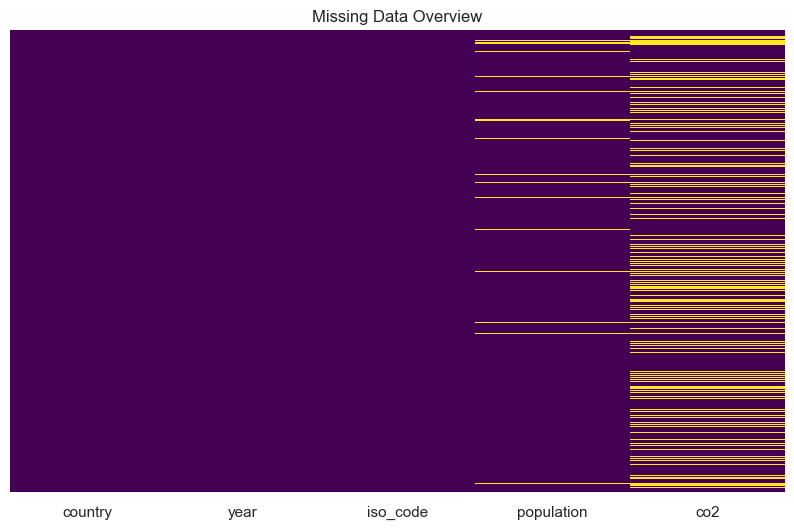

In [4]:
# merge the datasets on iso_code and year, append gdp to the right
merged_df = df.merge(
    gdp_long,
    on=['iso_code', 'year'],
    how='left',
    suffixes=('_co2', '_gdp')
)

# show the dataframe as heatmap to see where we have missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Overview")
plt.show()


## Per-Capita Metric Calculation

### Objective
Calculate per-capita values for CO2 emissions and GDP to enable meaningful cross-country comparisons that account for population differences.

### Rationale
Absolute values (total CO2, total GDP) are highly correlated with population size, making direct comparisons between countries misleading. Per-capita metrics normalize for population, revealing:
- **CO2 per capita**: Individual carbon footprint by country
- **GDP per capita**: Economic prosperity and development level

### Implementation Method

The calculation uses **vectorized NumPy operations** for computational efficiency:

1. **Extract Arrays**: Convert DataFrame columns to NumPy arrays for fast computation
   - `pop_arr`: Population values
   - `co2_arr`: CO2 emission values
   - `gdp_arr`: GDP values

2. **Safe Division with `np.divide()`**:
   - Performs element-wise division
   - Uses `where` parameter to avoid division by zero or invalid operations
   - Sets result to zero when population ≤ 0 using the `out` parameter
   - Handles NaN values gracefully (NaN/number = NaN)

3. **Create New Columns**:
   - `co2_per_capita`: CO2 emissions per person (million tonnes/person)
   - `gdp_per_capita`: GDP per person (USD/person)

### Mathematical Operation

```
co2_per_capita = co2 / population  (where population > 0)
gdp_per_capita = gdp / population  (where population > 0)
```

### Output
The `merged_df` dataframe now contains eight columns with both absolute and per-capita metrics, ready for comparative analysis across countries of different sizes.

In [5]:
# extract as numpy arrays
pop_arr = merged_df['population'].values
co2_arr = merged_df['co2'].values
gdp_arr = merged_df['gdp']

# vectorized division, check for NaN or invalid values and only calculate the correct values
merged_df['co2_per_capita'] = np.divide(co2_arr, pop_arr, out = np.zeros_like(co2_arr), where = pop_arr > 0)
merged_df['gdp_per_capita'] = np.divide(gdp_arr, pop_arr, out = np.zeros_like(gdp_arr), where = pop_arr > 0)



In [30]:
# random choice of countries to be compares
my_selection = ['Germany', 'United States', 'China', 'India']

# create a dataframe just for those countries
df_selected = merged_df[merged_df['country'].isin(my_selection)]

df_selected


,country,year,iso_code,population,co2,gdp,co2_per_capita,gdp_per_capita
5084,China,1901,CHN,397991980.0,NaN,NaN,NaN,NaN
5085,China,1902,CHN,400101986.0,NaN,NaN,NaN,NaN
5086,China,1903,CHN,402259874.0,NaN,NaN,NaN,NaN
5087,China,1904,CHN,404429383.0,NaN,NaN,NaN,NaN
5088,China,1905,CHN,406610574.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
25787,United States,2020,USA,339436156.0,4689.954,2.106047e+13,0.000014,62045.463457
25788,United States,2021,USA,340161438.0,5020.111,2.331508e+13,0.000015,68541.221771
25789,United States,2022,USA,341534041.0,5055.403,2.560485e+13,0.000015,74970.122547
25790,United States,2023,USA,343477330.0,4918.407,2.729217e+13,0.000014,79458.434107


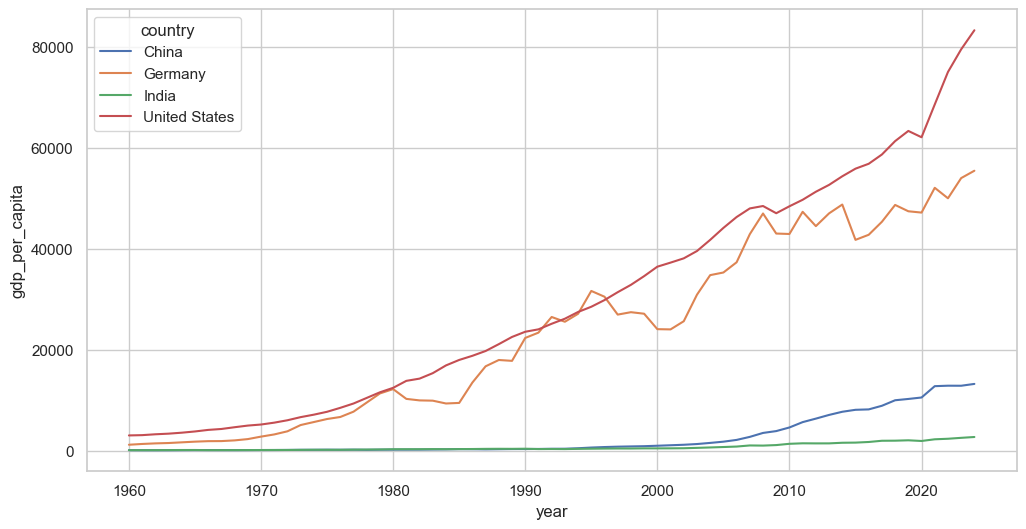

In [33]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_selected, x='year', y='gdp_per_capita', hue='country')
plt.show()